# Supply Chain Demand Prediction — 01 EDA

Daily order demand from the DataCo smart-supply-chain dataset (aggregated to one row per day). We explore trend and seasonality before forecasting.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_demand()
print('days:',len(df),'|',df.order_date.min().date(),'->',df.order_date.max().date())
print('demand: mean %.0f std %.0f'%(df.demand.mean(),df.demand.std()))

days: 1004 | 2015-01-01 -> 2017-09-30
demand: mean 374 std 39


## 1. Demand over time

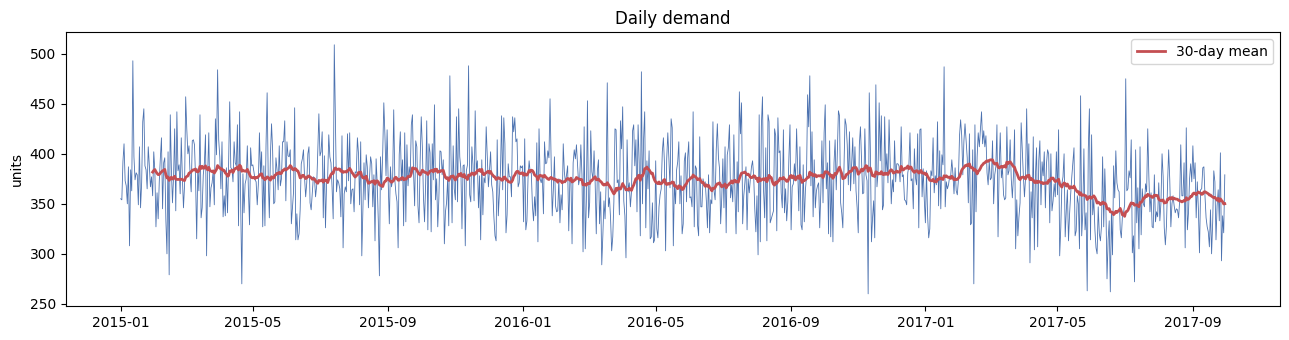

In [2]:
fig,ax=plt.subplots(figsize=(13,3.5)); ax.plot(df.order_date,df.demand,lw=0.6,color='#4c72b0'); ax.plot(df.order_date,df.demand.rolling(30).mean(),color='#c44e52',lw=2,label='30-day mean'); ax.legend(); ax.set_title('Daily demand'); ax.set_ylabel('units'); plt.tight_layout(); plt.show()

## 2. Distribution & weekly seasonality

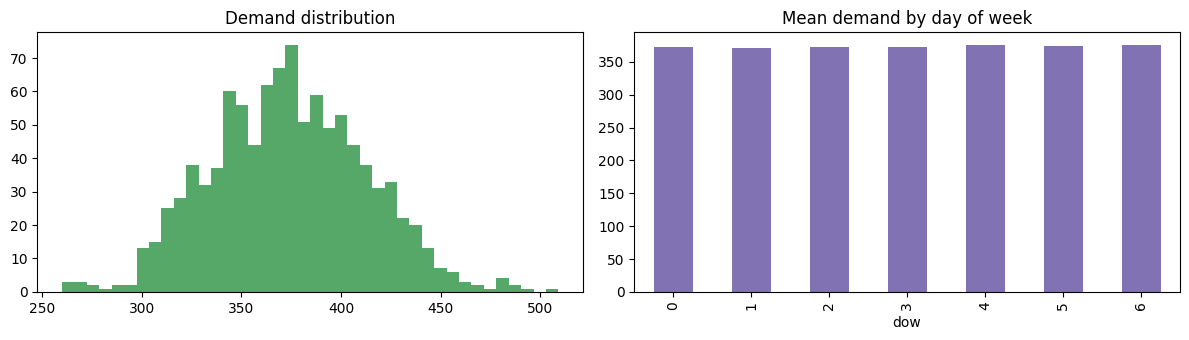

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df.demand,bins=40,color='#55a868'); ax[0].set_title('Demand distribution')
df.assign(dow=df.order_date.dt.dayofweek).groupby('dow').demand.mean().plot(kind='bar',ax=ax[1],color='#8172b3'); ax[1].set_title('Mean demand by day of week')
plt.tight_layout(); plt.show()

## 3. Summary

- ~1,000 days (2015–2017) after trimming the incomplete tail of the data dump.
- Demand is **smooth and near-stationary** (mean ~374, std ~39) — a low-variance series where 'predict roughly the average' is already decent.
- Notebook 02 engineers lag features and tests whether ML beats the naive baseline.